✓ 작업 디렉토리: e:\Dacon\open_track1\notebooks
✓ 프로젝트 루트: e:\Dacon\open_track1
✓ 라이브러리 로드 완료
✓ Pass 데이터: 178,582개
✓ 시각화 함수 로드 완료


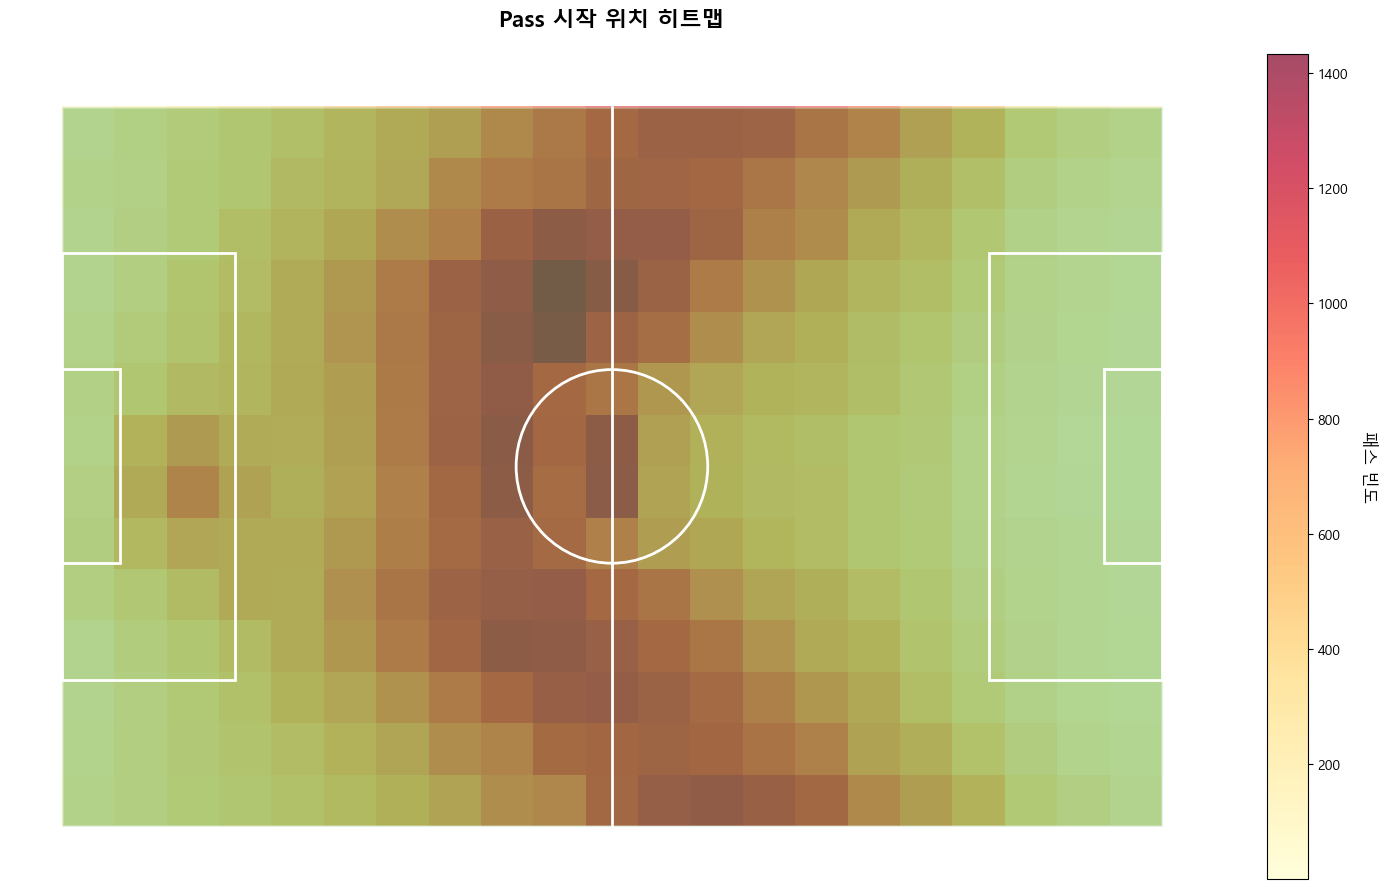

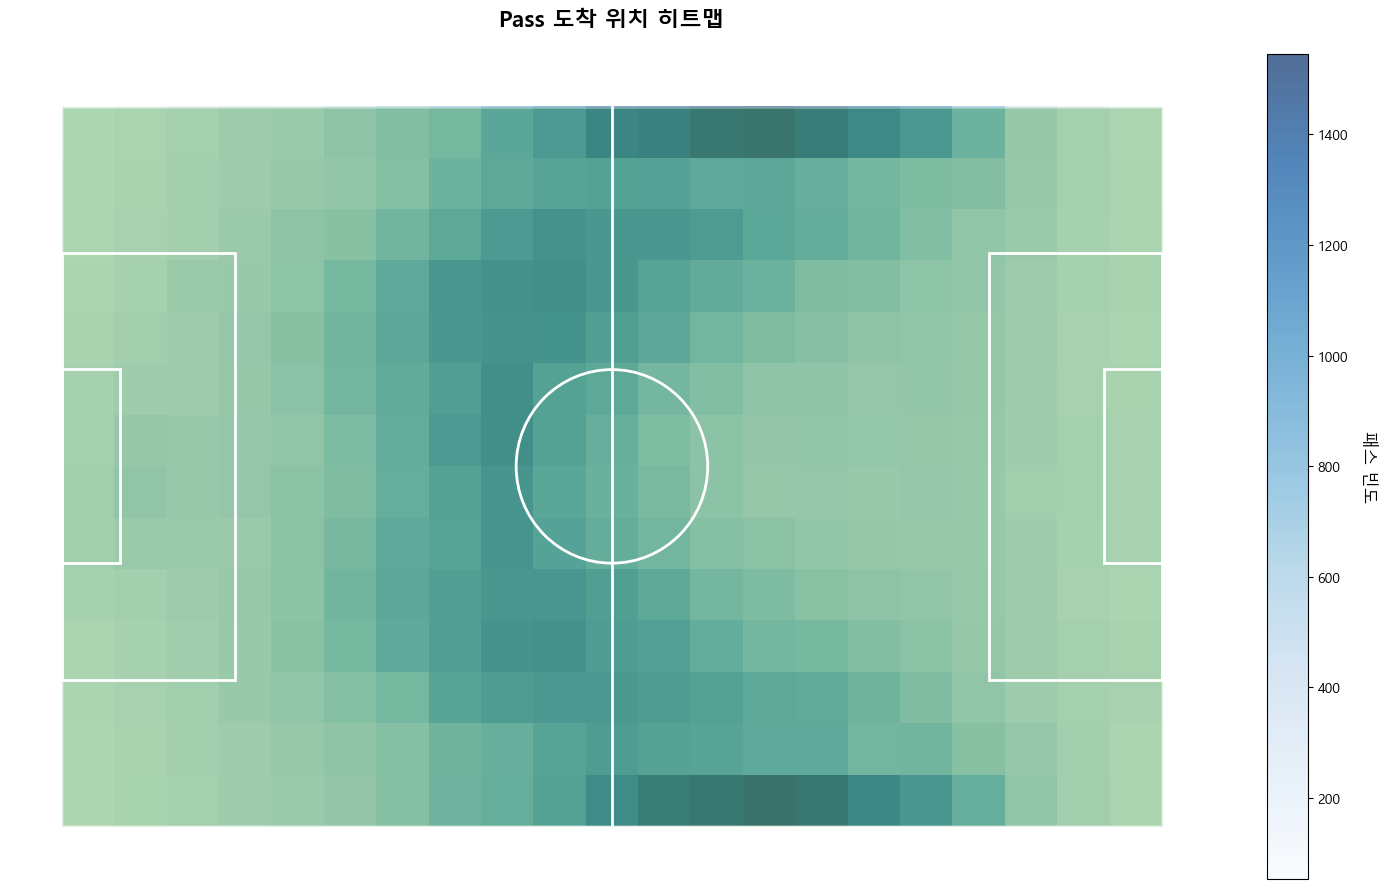

e:\Dacon\open_track1\src\visualization\field_viz.py:195: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
e:\Dacon\open_track1\src\visualization\field_viz.py:195: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\leo99\AppData\Local\Temp\ipykernel_34352\2590413421.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.savefig(project_root / 'docs/success_vs_fail.png', dpi=300, bbox_inches='tight')
C:\Users\leo99\AppData\Local\Temp\ipykernel_34352\2590413421.py:55: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Malgun Gothic.
  plt.savefig(project_root / 'docs/success_vs_fail.png', dpi=300, bbox_inches='tight')
e:\Dacon\open_track1\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io,

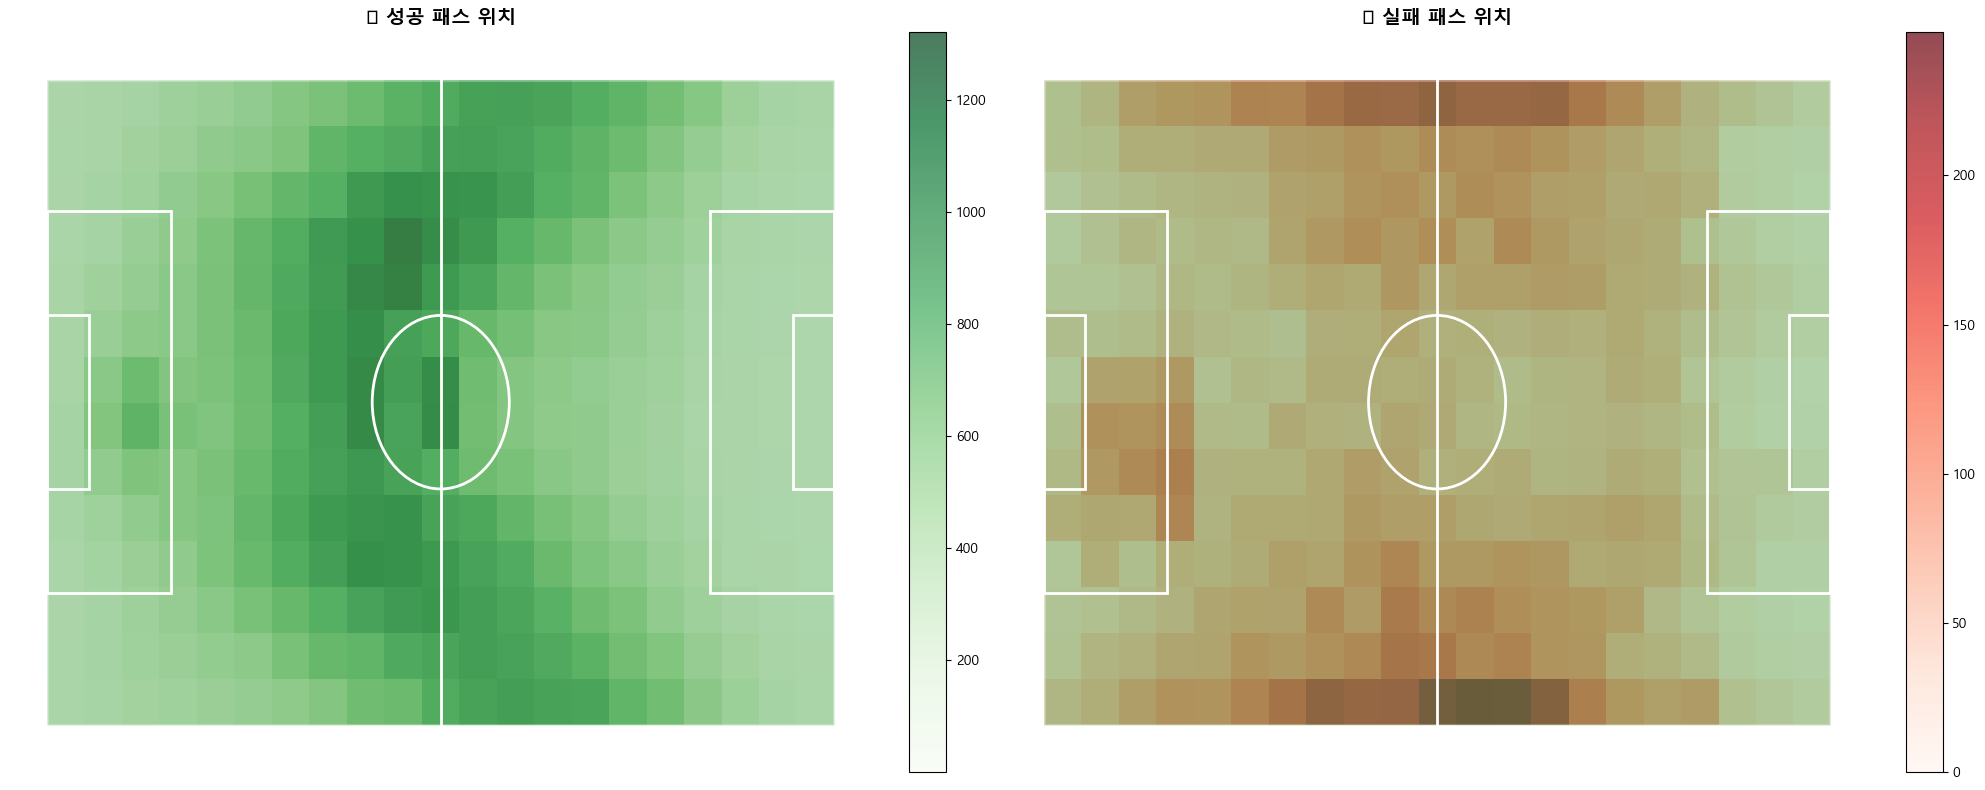

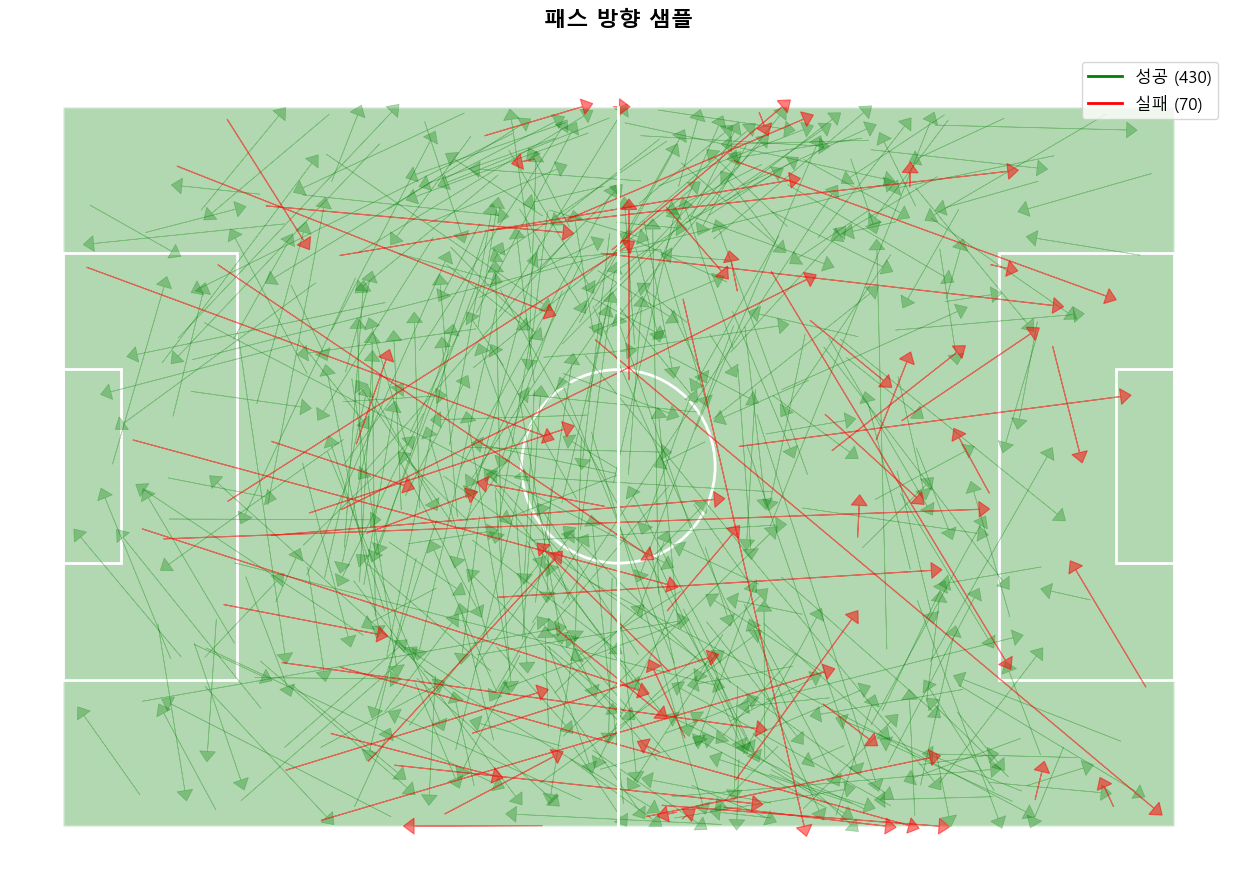

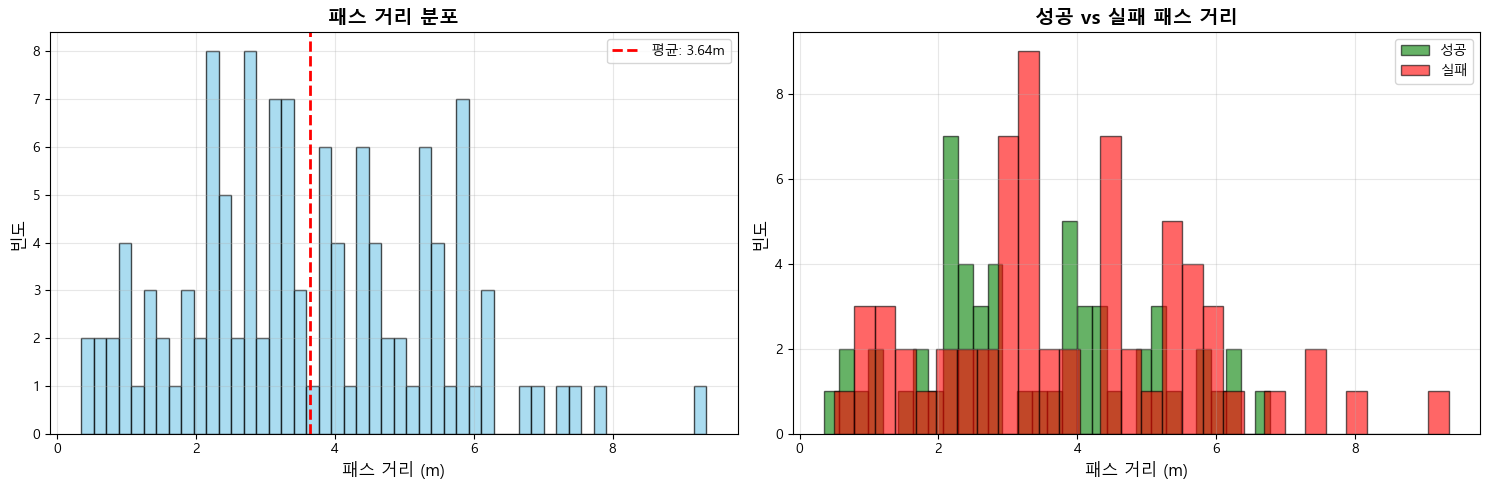

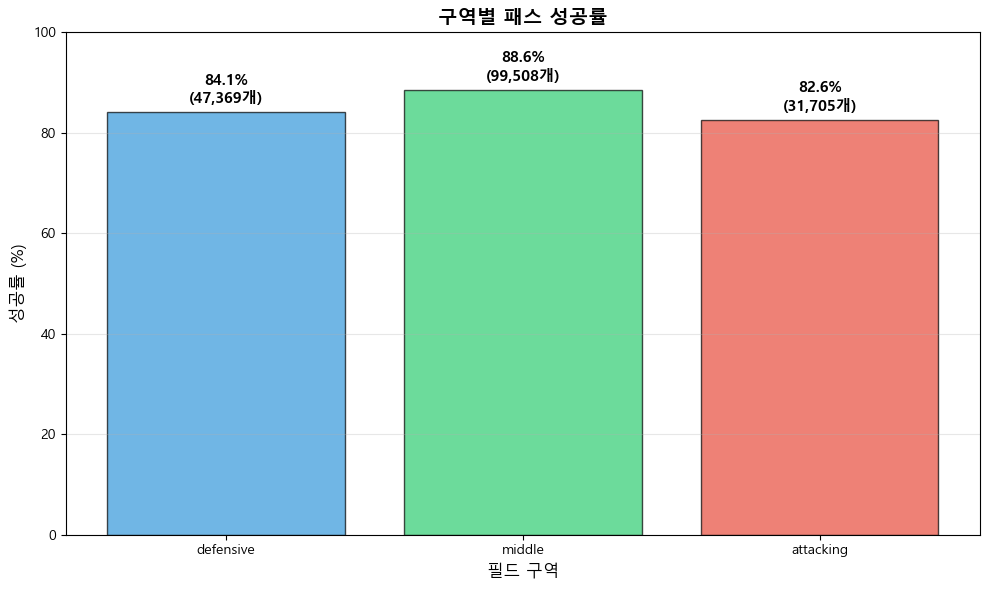


✅ 모든 시각화 완료!
✓ 그래프 저장 위치: e:\Dacon\open_track1\docs


In [1]:
import sys
from pathlib import Path

# 프로젝트 루트 추가
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

print(f"✓ 작업 디렉토리: {Path.cwd()}")
print(f"✓ 프로젝트 루트: {project_root}")

# 셀 2: 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("✓ 라이브러리 로드 완료")

# 셀 3: 데이터 로드
# 방법 A 사용 (또는 방법 B)
pass_df = pd.read_csv(project_root / 'data/processed/pass_method_a.csv')
print(f"✓ Pass 데이터: {len(pass_df):,}개")

# 셀 4: 시각화 함수 임포트
from src.visualization.field_viz import (
    plot_pass_heatmap,
    plot_pass_destination_heatmap,
    plot_success_vs_fail_comparison,
    plot_pass_arrows
)

from src.visualization.stats_viz import (
    plot_distance_distribution,
    plot_zone_success_rate
)

print("✓ 시각화 함수 로드 완료")

# 셀 5: 히트맵 - 시작 위치
fig1 = plot_pass_heatmap(pass_df)
plt.savefig(project_root / 'docs/pass_start_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 셀 6: 히트맵 - 도착 위치
fig2 = plot_pass_destination_heatmap(pass_df)
plt.savefig(project_root / 'docs/pass_end_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 셀 7: 성공 vs 실패 비교
fig3 = plot_success_vs_fail_comparison(pass_df)
plt.savefig(project_root / 'docs/success_vs_fail.png', dpi=300, bbox_inches='tight')
plt.show()

# 셀 8: 패스 화살표 (샘플)
fig4 = plot_pass_arrows(pass_df, sample_size=500)
plt.savefig(project_root / 'docs/pass_arrows.png', dpi=300, bbox_inches='tight')
plt.show()

# 셀 9: 거리 분포
fig5 = plot_distance_distribution(pass_df)
plt.savefig(project_root / 'docs/distance_dist.png', dpi=300, bbox_inches='tight')
plt.show()

# 셀 10: 구역별 성공률
fig6 = plot_zone_success_rate(pass_df)
plt.savefig(project_root / 'docs/zone_success_rate.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 모든 시각화 완료!")
print(f"✓ 그래프 저장 위치: {project_root / 'docs'}")

### 1. Pass 시작 위치 히트맵

    - 중앙 구역(middle) 집중 << 빌드업 중심
    - 중앙선 근처가 가장 뜨겁고, 양쪽 측면은 상대적으로 적음

    해석 :
    - 팀들이 측면 공격보다 중앙 빌드업을 선호함을 알 수 있음


### 2. Pass 도착 위치 히트맵

    - 시작 위치보다 넓게 분산
    - 중앙 -> 전방으로 확산되는 패턴
    - 공격 3분의 1 지역에 많은 패스

    해석 :
    - 중앙에서 시작해 전방으로 전개
    - 최종 3분의 1 지역 집중중

### 성공 vs 실패 Pass 비교
    - 성공 패스:
        - 양측에 집중
        - 상대적으로 균등한 분포
    
    - 실패 패스:
        - 중앙 우측과 공격 지역에 집중
        - 위험한 지역에서 실패율 높음
    
    - 핵심 인사이트:
        - 공격 지역으로 갈수록 실패 증가 -> 상대 압박이 강한 지역

### 패스 방향 샘플
    - 패턴 :
        - 초록(성공) >> 빨강(실패)
        - 성공 패스는 짧고 안전
        - 실패 패스는 길고 도전적

### 패스 거리 분포
    평균 : 3.64m

    왼쪽 그래프 (전체) :
        - 대부분 2-4m 사이
        - 매우 짧은 패스 중심
    
    오른쪽 그래프 :
        - 성공: 짧은 거리에 집중
        - 실패: 조금 더 긴 거리

### 구역별 성공률
    1. Middle: 88.6% (99,508개) ← 최고!
    2. Defensive: 84.1% (47,369개)
    3. Attacking: 82.6% (31,705개)

    핵심 인사이트:
    → 중앙 구역이 가장 안전
    → 공격 지역은 압박이 강해서 실패 증가
    → 수비 지역도 비교적 안전